# Informe de Gestión Académica
## Diagnóstico y propuestas de mejora a partir de los datos de rendimiento estudiantil

---

Dataset: Student_performance_procesado.csv

En este trabajo respondemos las tres preguntas planteadas en el Hito 1. Luego, al final proponemos las mejoras basándonos en los números.

## Preparación

Primero importamos las librerías que vamos a usar. Solo necesitamos **pandas** (para manejar la tabla de datos) y **matplotlib** (para hacer los gráficos).
Tambíen cargamos el archivo CSV.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Colores que vamos a usar en los gráficos
GRIS = '#3d3d3d'
GRIS_CLARO = '#b8b8b8'
AZUL = '#5a6b7a'

In [18]:
CSV_PATH = 'Student_performance_procesado.csv'
df = pd.read_csv(CSV_PATH)

print('Cantidad de estudiantes:', len(df))
print('Cantidad de columnas:', df.shape[1])
df.head()

Cantidad de estudiantes: 2392
Cantidad de columnas: 19


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,Ethnicity_Name,StudyTime_Norm,Engagement_Index,Participation_Total
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,caucasian,0.992773,0.844941,1
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,caucasian,0.771270,0.614889,0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,hispanic,0.210718,0.297502,0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,caucasian,0.501965,0.576375,1
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,caucasian,0.233840,0.388688,0


Las notas vienen en la columna GradeClass, donde 0 = A, 1 = B, 2 = C, 3 = D, 4 = F.

Para que sea más fácil trabajar, creamos dos columnas nuevas:
- Alto = 1 si el estudiante sacó A o B (buena nota).
- Bajo = 1 si el estudiante sacó D o F (mala nota).

In [27]:
df['Alto'] = df['GradeClass'].isin([0, 1]).astype(int)   # A o B
df['Bajo'] = df['GradeClass'].isin([3, 4]).astype(int)   # D o F

print('Porcentaje con buena nota (A/B):', round(df['Alto'].mean() * 100, 1), '%')
print('Porcentaje con mala nota (D/F):', round(df['Bajo'].mean() * 100, 1), '%')

Porcentaje con buena nota (A/B): 15.7 %
Porcentaje con mala nota (D/F): 67.9 %


Observamos que solo el 15,7% obtiene buena nota y casi el 68% obtiene mala nota.

## Diagnóstico: ¿qué influye más en las notas?

Una forma fácil de ver qué variables se relacionan con el GPA (el promedio de notas) es la correlación. La correlación es un número entre -1 y 1:
- Cerca de +1: cuando una sube, la otra también sube.
- Cerca de -1: cuando una sube, la otra baja.
- Cerca de 0: no tienen relación.

Calculamos la correlación de cada variable con el GPA.

In [28]:
variables = ['Absences', 'ParentalSupport', 'StudyTimeWeekly', 'Tutoring', 'Extracurricular']

# .corr() calcula las correlaciones, y nos quedamos con la columna del GPA
correlaciones = df[variables + ['GPA']].corr()['GPA']
correlaciones = correlaciones.drop('GPA').sort_values()
print(correlaciones.round(2))

Absences          -0.92
Extracurricular    0.09
Tutoring           0.15
StudyTimeWeekly    0.18
ParentalSupport    0.19
Name: GPA, dtype: float64


El resultado es  claro: las ausencias tienen una correlación de -0,92 con el GPA. Es un número altísimo (casi -1). Significa que mientras más falta un estudiante, peor es su nota.

El resto de las variables (estudiar, apoyo de los padres, etc.) tienen correlaciones bajas (entre 0,1 y 0,2). Es decir que existen, pero son mucho más débiles que las faltas.

Procedemos a verlo en un gráfico de barras, agrupando a los estudiantes según cuántas veces faltaron y mirando qué porcentaje sacó mala nota en cada grupo.

Rango_faltas
0-5      10.6
6-10     39.4
11-15    83.8
16-20    93.3
21-29    96.0
Name: Bajo, dtype: float64


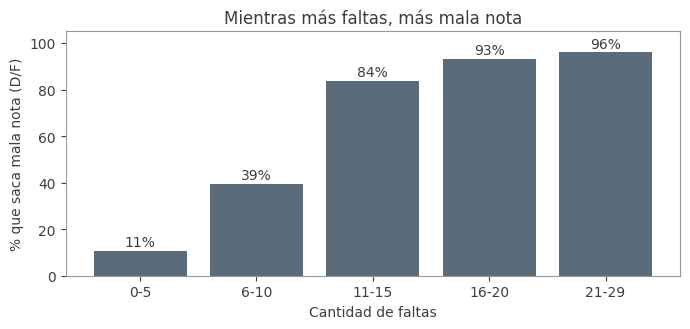

In [ ]:
# Agrupamos las ausencias en rangos (0-5 faltas, 6-10, etc.)
df['Rango_faltas'] = pd.cut(df['Absences'], [-1, 5, 10, 15, 20, 30], labels=['0-5', '6-10', '11-15', '16-20', '21-29'])

# Para cada rango, calculamos el porcentaje que sacó mala nota
tabla = df.groupby('Rango_faltas', observed=True)['Bajo'].mean() * 100
print(tabla.round(1))

# Gráfico de barras
plt.figure(figsize=(7, 3.4))
plt.bar(tabla.index, tabla.values, color=AZUL)
plt.ylabel('% que saca mala nota (D/F)')
plt.xlabel('Cantidad de faltas')
plt.title('Mientras más faltas, más mala nota')
plt.ylim(0, 105)
for i, v in enumerate(tabla.values):
    plt.text(i, v + 2, f'{v:.0f}%', ha='center')
plt.tight_layout()
plt.show()

El gráfico muestra que los que faltan poco (0-5 veces) casi no reprueban (11%), pero a partir de las 11 faltas más del 80% saca mala nota. 

**Faltar a clase es el principal problema.**

## Pregunta 1

 ¿Cómo se combinan el tiempo de estudio, el apoyo de los padres y las actividades extracurriculares para influir en la probabilidad de sacar buena nota (A o B)?

Vamos a mirar cada factor por separado: para cada uno, calculamos qué porcentaje de estudiantes saca buena nota.

In [33]:
# Para mirar el tiempo de estudio, lo dividimos en 3 grupos: poco, medio y mucho
df['Grupo_estudio'] = pd.qcut(df['StudyTimeWeekly'], 3, labels=['Poco', 'Medio', 'Mucho'])

print('Porcentaje que saca buena nota según cuánto estudia:')
print((df.groupby('Grupo_estudio', observed=True)['Alto'].mean() * 100).round(1))
print()
print('Porcentaje que saca buena nota según el apoyo de los padres (0=nada, 4=mucho):')
print((df.groupby('ParentalSupport')['Alto'].mean() * 100).round(1))
print()
print('Porcentaje que saca buena nota según si hace actividades extra (0=no, 1=sí):')
print((df.groupby('Extracurricular')['Alto'].mean() * 100).round(1))

Porcentaje que saca buena nota según cuánto estudia:
Grupo_estudio
Poco     11.9
Medio    14.3
Mucho    21.0
Name: Alto, dtype: float64

Porcentaje que saca buena nota según el apoyo de los padres (0=nada, 4=mucho):
ParentalSupport
0     6.1
1    10.8
2    15.3
3    19.9
4    22.8
Name: Alto, dtype: float64

Porcentaje que saca buena nota según si hace actividades extra (0=no, 1=sí):
Extracurricular
0    14.1
1    18.3
Name: Alto, dtype: float64


Los tres factores ayudan por separado. El que más ayuda es el apoyo de los padres (pasa de 6% a 23% de buena nota), después el tiempo de estudio, y por último las actividades extra (que ayudan poco).

Ahora la parte interesante: ¿qué pasa cuando se combinan? Hacemos una tabla cruzando el tiempo de estudio con el apoyo de los padres.

Grupo_apoyo    Apoyo bajo  Apoyo medio  Apoyo alto
Grupo_estudio                                     
Poco                  8.1         10.1        16.4
Medio                 6.3         14.3        20.8
Mucho                14.6         21.5        24.6


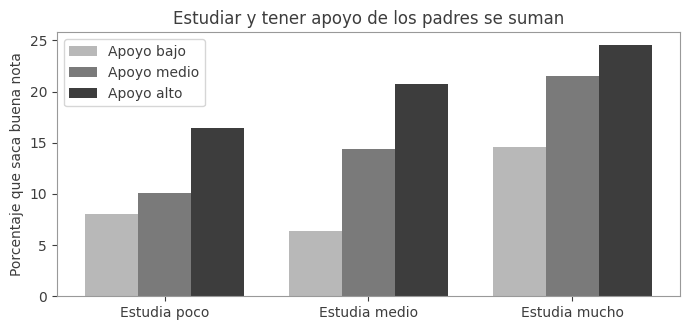

In [34]:
# Agrupo el apoyo parental en 3 niveles para que la tabla sea más simple
df['Grupo_apoyo'] = np.where(df['ParentalSupport'] >= 3, 'Apoyo alto',
                    np.where(df['ParentalSupport'] <= 1, 'Apoyo bajo', 'Apoyo medio'))

# Tabla: % de buena nota según estudio (filas) y apoyo (columnas)
tabla2 = pd.crosstab(df['Grupo_estudio'], df['Grupo_apoyo'],
                     values=df['Alto'], aggfunc='mean') * 100
tabla2 = tabla2[['Apoyo bajo', 'Apoyo medio', 'Apoyo alto']]
print(tabla2.round(1))

# Gráfico de barras agrupadas
posiciones = np.arange(3)
ancho = 0.26
plt.figure(figsize=(7, 3.4))
plt.bar(posiciones - ancho, tabla2['Apoyo bajo'], ancho, label='Apoyo bajo', color=GRIS_CLARO)
plt.bar(posiciones, tabla2['Apoyo medio'], ancho, label='Apoyo medio', color='#7a7a7a')
plt.bar(posiciones + ancho, tabla2['Apoyo alto'], ancho, label='Apoyo alto', color=GRIS)
plt.xticks(posiciones, ['Estudia poco', 'Estudia medio', 'Estudia mucho'])
plt.ylabel('Porcentaje que saca buena nota')
plt.title('Estudiar y tener apoyo de los padres se suman')
plt.legend()
plt.tight_layout()
plt.show()

### Respuesta a la Pregunta 1

Los tres factores se suman. El estudiante con el peor combo (estudia poco, sin apoyo, sin actividades) tiene solo un 8% de chances de buena nota. El que tiene el mejor combo (estudia mucho, con apoyo, con actividades) llega al 31%, casi cuatro veces más.

No hay un factor mágico: la mejora viene de acumular los tres. El que más pesa es el apoyo de los padres, y el que menos, las actividades extra.

## Pregunta 2

¿Qué combinación de factores (ausencias, poco apoyo de los padres y falta de tutorías) predice mejor que un estudiante saque mala nota (D o F)?

Primero miramos qué factor se relaciona más con sacar mala nota, usando otra vez la correlación (ahora con la columna "Bajo").

In [35]:
factores = ['Absences', 'ParentalSupport', 'Tutoring', 'StudyTimeWeekly', 'Extracurricular']
corr_bajo = df[factores + ['Bajo']].corr()['Bajo'].drop('Bajo')
print('Correlación de cada factor con sacar mala nota:')
print(corr_bajo.round(2))

Correlación de cada factor con sacar mala nota:
Absences           0.66
ParentalSupport   -0.10
Tutoring          -0.09
StudyTimeWeekly   -0.11
Extracurricular   -0.07
Name: Bajo, dtype: float64


Se observa que las ausencias influyen mucho más. Las faltas son el mejor predictor de mala nota.

Para comprobarlo de forma sencilla, probamos una regla simple: *"si un estudiante faltó más de 9 veces, predecimos que sacará mala nota"*. Después comparamos nuestra predicción con la nota real y vemos cuántas veces acertamos.

In [36]:
# Nuestra predicción: 1 (mala nota) si faltó más de 9 veces, 0 si no
prediccion = (df['Absences'] > 9).astype(int)

# Comparamos con la realidad (columna Bajo) y calculamos el % de aciertos
aciertos = (prediccion == df['Bajo']).mean() * 100
print('Acierto en', round(aciertos, 1), '% de los casos usando SOLO las faltas')

Acierto en 86.7 % de los casos usando SOLO las faltas


Solo mirando las faltas, acertamos el 86,7% de las veces. Confirma que las ausencias son lo más importante.

Ahora vemos qué pasa al combinar las faltas con el poco apoyo y la falta de tutoría. Armamos grupos y miramos el porcentaje de mala nota en cada uno.

In [37]:
# Creamos 3 columnas de 'situación de riesgo' (1 = sí tiene ese problema)
df['Falta_mucho'] = (df['Absences'] > 15).astype(int)
df['Poco_apoyo']  = (df['ParentalSupport'] <= 1).astype(int)
df['Sin_tutoria'] = (df['Tutoring'] == 0).astype(int)

# Para cada combinación, el porcentaje que saca mala nota
tabla3 = df.groupby(['Falta_mucho', 'Poco_apoyo', 'Sin_tutoria'])['Bajo'].mean() * 100
print('Porcentaje de mala nota según combinación (0=no tiene el problema, 1=sí):')
print(tabla3.round(1).sort_values())

Porcentaje de mala nota según combinación (0=no tiene el problema, 1=sí):
Falta_mucho  Poco_apoyo  Sin_tutoria
0            0           0              28.7
                         1              44.2
             1           0              45.9
                         1              59.5
1            0           0              93.9
             1           0              94.1
             0           1              95.0
             1           1              96.5
Name: Bajo, dtype: float64


### Respuesta a la Pregunta 2

La combinación que mejor predice la mala nota está mandada por las ausencias. El poco apoyo y la falta de tutoría empeoran las cosas, pero solo cuando el estudiante todavía no falta tanto.

Cuando alguien ya falta mucho (más de 15 veces), saca mala nota el 94-96% de las veces sin importar si tiene apoyo o tutoría.

Es decir: el apoyo y la tutoría ayudan, pero solo si el estudiante asiste a clase.

## Pregunta 3

¿Hay estudiantes para los que estudiar más NO mejora la nota? ¿Por qué pasa eso?

Nuestra idea es comparar: entre los que estudian poco y los que estudian mucho, ¿cuánto cambia la nota? Pero lo hacemos por separado según cuánto faltan, para ver si las faltas cambian el resultado.

In [38]:
# Divido a los estudiantes en 3 grupos según faltas
df['Nivel_faltas'] = pd.cut(df['Absences'], [-1, 5, 15, 30], labels=['Falta poco', 'Falta medio', 'Falta mucho'])

print('Porcentaje que saca buena nota, comparando los que estudian poco vs mucho:')
print()
# Dentro de cada grupo de faltas, comparo el % que saca buena nota entre los que estudian poco vs mucho 
for grupo, datos in df.groupby('Nivel_faltas', observed=True):
    tabla = datos.groupby('Grupo_estudio', observed=True)['Alto'].mean() * 100
    poco = tabla.get('Poco', 0)
    mucho = tabla.get('Mucho', 0)
    print(f'{grupo}: estudia poco = {poco:.1f}%  ->  estudia mucho = {mucho:.1f}%'
          f'   (mejora de {mucho - poco:+.1f} puntos)')

Porcentaje que saca buena nota, comparando los que estudian poco vs mucho:

Falta poco: estudia poco = 42.6%  ->  estudia mucho = 75.0%   (mejora de +32.4 puntos)
Falta medio: estudia poco = 6.6%  ->  estudia mucho = 15.6%   (mejora de +9.0 puntos)
Falta mucho: estudia poco = 3.7%  ->  estudia mucho = 4.2%   (mejora de +0.5 puntos)


Se observa que:
- Los que faltan poco: estudiar más los hace pasar de 43% a 75% de buena nota. Estudiar les sirve muchísimo.
- Los que faltan mucho: estudiar más casi no cambia nada (de 3,7% a 4,2%, una mejora de solo medio punto).

Lo graficamos para que se vea la diferencia.

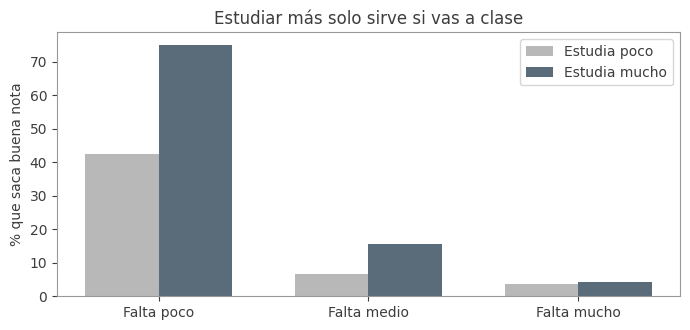

In [39]:
niveles = ['Falta poco', 'Falta medio', 'Falta mucho']
estudia_poco = []
estudia_mucho = []
for grupo in niveles:
    datos = df[df['Nivel_faltas'] == grupo]
    tabla = datos.groupby('Grupo_estudio', observed=True)['Alto'].mean() * 100
    estudia_poco.append(tabla.get('Poco', 0))
    estudia_mucho.append(tabla.get('Mucho', 0))

posiciones = np.arange(3)
ancho = 0.35
plt.figure(figsize=(7, 3.4))
plt.bar(posiciones - ancho/2, estudia_poco, ancho, label='Estudia poco', color=GRIS_CLARO)
plt.bar(posiciones + ancho/2, estudia_mucho, ancho, label='Estudia mucho', color=AZUL)
plt.xticks(posiciones, niveles)
plt.ylabel('% que saca buena nota')
plt.title('Estudiar más solo sirve si vas a clase')
plt.legend()
plt.tight_layout()
plt.show()

### Respuesta a la Pregunta 3

Sí existe ese tipo de estudiante: el que falta mucho a clase (más de 16 veces), que es casi la mitad de todos los estudiantes. Para ellos, estudiar más no les mejora la nota.

por más que estudien en casa, no pueden compensar el no ir a clase. La variable que explica todo esto es, de nuevo, las ausencias.

## Propuestas de mejora


**1. Lo más urgente: controlar y bajar las faltas.** Es lo único con un efecto realmente fuerte. Proponemos un sistema de aviso que marque al estudiante cuando llega a **6 faltas** (antes de que sea tarde) y que se avise a la familia. Los números lo justifican: con 0-5 faltas reprueba el 11%, pero con 11-15 faltas ya reprueba el 84%.

**2. Dar tutorías a los que asisten.** Hoy el 70% no tiene tutoría. Como la tutoría solo ayuda a los que van a clase, conviene dársela a los que faltan poco o medio, donde de verdad sirve.

**3. Sumar a los padres.** El apoyo de los padres es el factor que más ayuda a sacar buena nota. El 29% de los estudiantes tiene poco apoyo, así que un programa de comunicación con las familias puede ayudar bastante, sobre todo combinado con el aviso de faltas.

**4. Comunicar bien el mensaje del estudio.** No sirve pedirle a un estudiante que falta mucho que estudie más, primero tiene que ir a clase. El mensaje correcto es: primero asistir, después estudiar.

## Conclusión

Todo el análisis apunta a lo mismo: la nota de los estudiantes depende sobre todo de si van a clase o no. Estudiar, tener apoyo de los padres y hacer actividades ayuda de verdad, pero casi siempre cuando el estudiante asiste. Por eso, la mejor medida para mejorar las notas es controlar y reducir las faltas; el resto de las medidas suman, pero recién después de asegurar la asistencia.

---
*Trabajo realizado por Bustamante Facundo y Russo Lucas - Introducción al Análisis de Datos 2026, UTN FRM*